# Lesson 28: TensorFlow/Keras neural network demonstration - part 2

## Notebook set up

### Vocareum compatibility

Check the notebook path to determine if we are running in Vocareum, if so, install TensorFlow 2.17 and Keras 3.2.0 via pip.

In [1]:
from pathlib import Path

# Get the parts of the current directory path as a tuple
path_parts = Path.cwd().parts

# Check if 'voc' is the first directory level
is_voc_root = len(path_parts) > 1 and path_parts[1] == "voc"

# If we are in a Vocareum instance, upgrade TensorFlow and Keras
if is_voc_root:
    print("Running in Vocareum environment")

    get_ipython().run_line_magic(
        "pip", "install -qq --no-warn-script-location tensorflow==2.17.0 keras==3.2.0"
    )

Running in Vocareum environment
Note: you may need to restart the kernel to use updated packages.


### Imports

In [ ]:
# Suppress noisy TensorFlow logs before importing
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard

### GPU configuration (if present)

In [ ]:
# Configure GPU settings
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Use only GPU 0
        tf.config.set_visible_devices(gpus[0], 'GPU')

        # Enable memory growth
        tf.config.experimental.set_memory_growth(gpus[0], True)

        # Get GPU
        details = tf.config.experimental.get_device_details(gpus[0])
        cc = details.get('compute_capability', (0, 0))
        device = details.get('device_name', '')

        print(f'Using GPU: {device}, compute capability {cc[0]}.{cc[1]}')
        print('Memory growth enabled')

    except RuntimeError as e:
        print(e)

else:
    print('No GPU found')

## 1. Load California housing data

Load the preprocessed data from part 1 of the demo:

In [ ]:
data = pd.read_pickle('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/preprocessed_housing_data.pkl')
print(f'Data dictionary contains: {list(data.keys())}')

Data dictionary contains: ['training_df', 'testing_df', 'features', 'label', 'feature_scaler', 'label_scaler']


In [5]:
training_df = data['training_df']
testing_df = data['testing_df']
features = data['features']
label = data['label']

## 2. Build model

In [6]:
tf.random.set_seed(315)

model = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,513 (17.63 KB)

 Trainable params: 4,513 (17.63 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Callbacks

1. [Custom callbacks](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/Callback)
2. [Early stopping callback](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping)
3. [Model checkpoint](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint)
4. [Tensorboard](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/TensorBoard)

To start tensorboard via a terminal, run:

```bash
tensorboard --logdir=path/to/log_dir/from/notebook_dir
```

Then visit the URL provided in your browser or via the 'ports' tab in VS Code. **Note**: if you are using the course's containerized deeplearning environment, you do not need to start TensorBoard manually. You can access it via the command pallette under `Python: Launch TensorBoard`.

Alternatively, if you are using a Jupyter notebook in a remote environment (Such as vocareum or CoLab) you can run TensorBoard inline with these cell magics:

```bash
%load_ext tensorboard
%tensorboard --logdir path/to/log_dir/from/notebook_dir
```

In [7]:
es_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

tensorboard = TensorBoard(
    log_dir='./logs',
    histogram_freq=1,
    write_graph=True
)

## 4. Train model

In [8]:
%%time

history = model.fit(
    training_df[features],
    training_df[label],
    epochs=500,
    batch_size=128,
    validation_split=0.2,
    callbacks=[checkpoint, tensorboard],
    verbose=0
)

print('Training complete.')
print(f'Final training loss: {history.history["loss"][-1]:.4f}')
print(f'Final validation loss: {history.history["val_loss"][-1]:.4f}')

Training complete.
Final training loss: 0.2343
Final validation loss: 0.2418
CPU times: user 2min 8s, sys: 8.38 s, total: 2min 16s
Wall time: 1min 48s


## 5. Learning curves

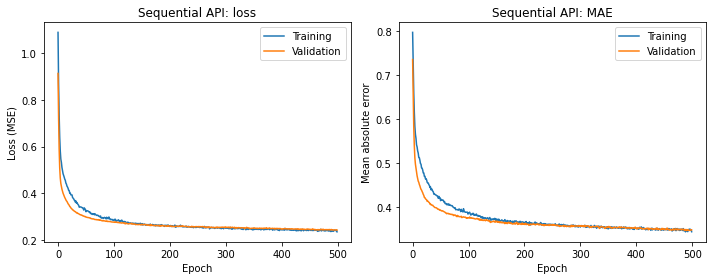

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Sequential API: loss')
axes[0].plot(history.history['loss'], label='Training')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend(loc='best')

axes[1].set_title('Sequential API: MAE')
axes[1].plot(history.history['mae'], label='Training')
axes[1].plot(history.history['val_mae'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean absolute error')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

## 6. Test set evaluation

In [10]:
predictions = model.predict(testing_df[features], verbose=0).flatten()

ss_res = np.sum((testing_df[label] - predictions) ** 2)
ss_tot = np.sum((testing_df[label] - np.mean(testing_df[label])) ** 2)
rsquared = 1 - (ss_res / ss_tot)

print(f'Model R² on test set: {rsquared:.4f}')

Model R² on test set: 0.7696


## 7. Performance analysis

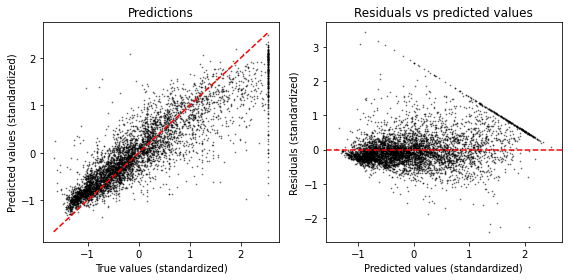

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].set_title('Predictions')
axes[0].scatter(
    testing_df[label], predictions,
    c='black', s=0.5, alpha=0.5
)

axes[0].plot(
    [testing_df[label].min(), testing_df[label].max()],
    [testing_df[label].min(), testing_df[label].max()],
    color='red', linestyle='--'
)

axes[0].set_xlabel('True values (standardized)')
axes[0].set_ylabel('Predicted values (standardized)')

axes[1].set_title('Residuals vs predicted values')
axes[1].scatter(
    predictions, testing_df[label] - predictions,
    c='black', s=0.5, alpha=0.5
)

axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted values (standardized)')
axes[1].set_ylabel('Residuals (standardized)')

plt.tight_layout()
plt.show()

## 8. Save the model

In [12]:
model.save('housing_price_model_sequential_api.keras')

## 9. Load the model

In [13]:
loaded_model = keras.models.load_model('housing_price_model_sequential_api.keras')
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,541 (52.90 KB)

 Trainable params: 4,513 (17.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,028 (35.27 KB)